# 02 — Data Cleaning & Pipeline
## PurpleAir QC → LRAPA Correction → Three-way Merge → Save

Steps in this notebook:
1. A/B channel quality control on PurpleAir sensors
2. Apply LRAPA correction to raw CF=1 readings
3. Validate PurpleAir (corrected) against LRAPA regulatory monitors
4. Clean NOAA weather data
5. Aggregate sensors → single hourly mean per timestamp
6. Inner-join all three datasets on timestamp
7. Add engineered features (wind components, rolling, lag) **within each fire event**
8. Save analysis-ready dataset to `data/processed/`

The combined file includes both **Holiday Farm Fire 2020** and **Cedar Creek Fire 2022**.
Lags and rolling windows reset at each event boundary (no cross-season leakage).

In [1]:
import sys, pathlib
sys.path.append("../src")

from data_loader import PurpleAirLoader, NOAALoader, LRAPALoader
from preprocessing import (DataCleaner, TimeAligner, DataMerger,
                           aggregate_purpleair_sensors,
                           create_full_analysis_dataset)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

pathlib.Path("../data/processed").mkdir(exist_ok=True)

## 1. Load Raw Data

In [2]:
pa_raw    = PurpleAirLoader("../data/raw/purpleair").load_all_sensors_in_directory()
noaa_raw  = NOAALoader("../data/raw/noaa").load_all_weather_data()
lrapa_raw = LRAPALoader("../data/raw/lrapa").load_all_lrapa_data()

# Filter NOAA to EUG station only (drop the 77S auxiliary)
noaa_eug = noaa_raw[noaa_raw['station'] == 'EUG'].copy()
print(f"\nPurpleAir: {pa_raw['sensor_id'].nunique()} sensors, {len(pa_raw):,} records")
print(f"NOAA EUG:  {len(noaa_eug):,} sub-hourly records")
print(f"LRAPA:     {len(lrapa_raw):,} hourly records")

Skipping bogus export(s) (filename starts with space; empty/failed download — you can delete these files):
  ../data/raw/purpleair/PurpleAir Download 5-5-2026/ 2022-08-01 2022-09-30 60-Minute Average.csv
  ../data/raw/purpleair/PurpleAir Download 5-17-2026/ 2020-08-01 2020-10-15 60-Minute Average.csv
Found 79 sensor data files
Detected data source: metar
Detected data source: metar
Loaded 1824 LRAPA records from LRAPAHourlyDataExport05172026-2.xlsx
Date range: 2020-08-01 02:00:00-07:00 → 2020-10-16 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
Loaded 1464 LRAPA records from LRAPAHourlyDataExport05052026-2.xlsx
Date range: 2022-08-01 02:00:00-07:00 → 2022-10-01 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']

PurpleAir: 52 sensors, 87,167 records
NOAA EUG:  5,932 sub-hourly records
LRAPA:     3,288 hourly records


## 2. PurpleAir QC — A/B Channel Agreement

Each PurpleAir unit has two independent laser sensors (channels A and B).
Readings are flagged and removed when the channels disagree by > 5 µg/m³ AND
their ratio is < 70% — indicating a malfunctioning sensor or contamination.

A/B QC: flagged 6943 records (8.0%) with channel disagreement
A/B flag rate: 7.97% of all readings


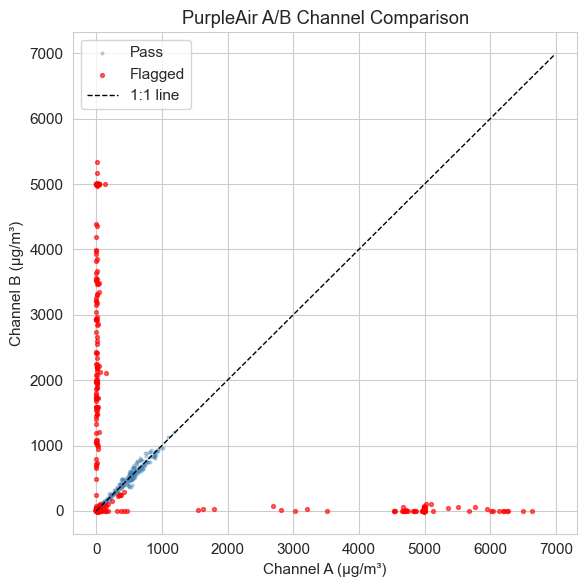

In [3]:
cleaner = DataCleaner()

# Flag A/B disagreements before dropping
pa_flagged = cleaner.flag_ab_channel_disagreement(pa_raw)
flag_pct = pa_flagged['ab_channel_flag'].mean() * 100
print(f"A/B flag rate: {flag_pct:.2f}% of all readings")

# Scatter plot: A vs B (colored by flag)
sample = pa_flagged.sample(min(5000, len(pa_flagged)), random_state=42)
fig, ax = plt.subplots(figsize=(6, 6))
ok   = sample[~sample['ab_channel_flag']]
bad  = sample[sample['ab_channel_flag']]
ax.scatter(ok['pm2.5_cf_1_a'],  ok['pm2.5_cf_1_b'],  s=4, alpha=0.3, color='steelblue', label='Pass')
ax.scatter(bad['pm2.5_cf_1_a'], bad['pm2.5_cf_1_b'],  s=8, alpha=0.6, color='red', label='Flagged')
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
ax.set_xlabel('Channel A (µg/m³)')
ax.set_ylabel('Channel B (µg/m³)')
ax.set_title('PurpleAir A/B Channel Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_ab_qc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Apply LRAPA Correction

The LRAPA (Lane Regional Air Protection Agency) correction adjusts PurpleAir
CF=1 readings to better match regulatory-grade instruments:

**PM2.5_corrected = 0.5 × CF_1 - 0.66**

This formula was developed locally for Eugene/Lane County and validated against
LRAPA professional monitors, particularly during wildfire smoke events.

A/B QC: flagged 6943 records (8.0%) with channel disagreement
Dropped 6943 A/B-flagged records
Applied LRAPA correction to 'pm2.5_cf_1_a / pm2.5_cf_1 (coalesced)' → 'pm2.5_lrapa'


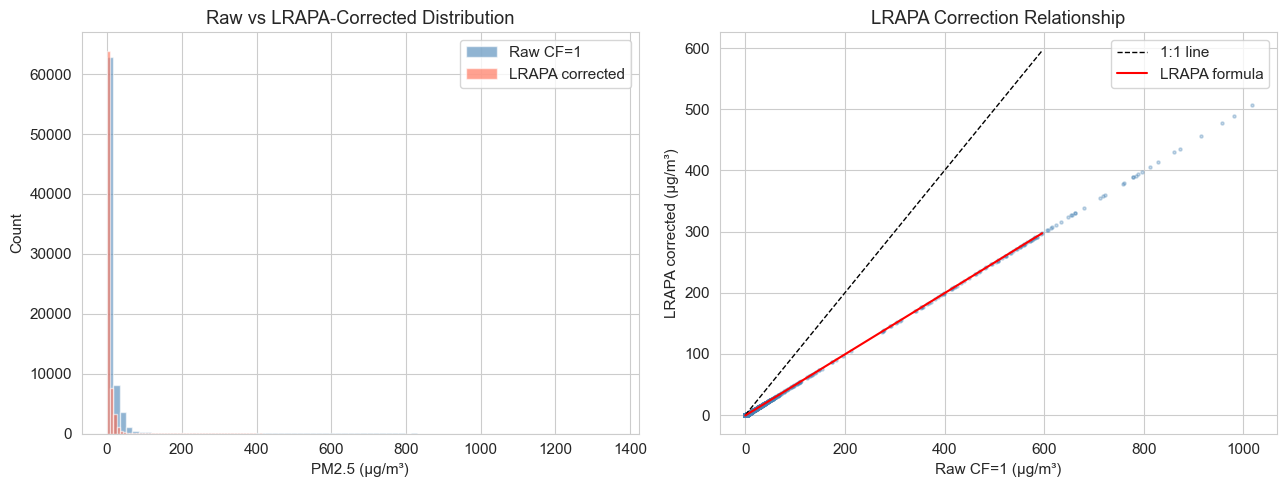


Mean raw:       31.73 µg/m³
Mean corrected: 15.28 µg/m³


In [4]:
# Full PurpleAir clean: A/B QC + LRAPA correction + range filter
pa_clean = cleaner.clean_purpleair_data(pa_raw, apply_lrapa=True, drop_ab_flagged=True)

# Show correction effect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram comparison
ax = axes[0]
ax.hist(pa_clean['pm2.5_cf_1_a'].dropna(), bins=80, alpha=0.6, color='steelblue', label='Raw CF=1')
ax.hist(pa_clean['pm2.5_lrapa'].dropna(),   bins=80, alpha=0.6, color='tomato',    label='LRAPA corrected')
ax.set_xlabel('PM2.5 (µg/m³)')
ax.set_ylabel('Count')
ax.set_title('Raw vs LRAPA-Corrected Distribution')
ax.legend()

# Scatter: raw vs corrected (sample)
ax = axes[1]
s = pa_clean.sample(min(3000, len(pa_clean)), random_state=42)
ax.scatter(s['pm2.5_cf_1_a'], s['pm2.5_lrapa'], s=5, alpha=0.3, color='steelblue')
lim = s['pm2.5_cf_1_a'].quantile(0.99)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
# Draw the LRAPA correction line
x = np.linspace(0, lim, 100)
ax.plot(x, 0.5*x - 0.66, 'r-', linewidth=1.5, label='LRAPA formula')
ax.set_xlabel('Raw CF=1 (µg/m³)')
ax.set_ylabel('LRAPA corrected (µg/m³)')
ax.set_title('LRAPA Correction Relationship')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_lrapa_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMean raw:       {pa_clean['pm2.5_cf_1_a'].mean():.2f} µg/m³")
print(f"Mean corrected: {pa_clean['pm2.5_lrapa'].mean():.2f} µg/m³")

## 4. Validate PurpleAir Against LRAPA Regulatory Data

Two comparisons, shown in order:

1. **Raw CF=1 (uncorrected)** PurpleAir median vs LRAPA regulatory — reveals the systematic high bias at elevated concentrations.
2. **LRAPA-corrected** PurpleAir median vs LRAPA regulatory — shows how the formula (0.5 × CF₁ − 0.66) removes that bias.

Both comparisons are split by fire event (2020 red, 2022 blue) so the gap between seasons does not compress the scales.


In [ ]:
# Aggregate raw (uncorrected) CF=1 PA readings to hourly median for comparison
pa_hourly_raw = pa_clean.groupby('timestamp')['pm2.5_cf_1_a'].median().reset_index()
pa_hourly_raw.columns = ['timestamp', 'pm2.5_pa_raw']

val_raw = pd.merge(
    pa_hourly_raw,
    lrapa_raw[['timestamp', 'pm2.5_lrapa_regulatory']],
    on='timestamp',
    how='inner',
).dropna()

event_map = {2020: 'Holiday Farm Fire 2020', 2022: 'Cedar Creek Fire 2022'}
val_raw['event'] = val_raw['timestamp'].dt.year.map(event_map)
events = [e for e in event_map.values() if e in val_raw['event'].values]
event_colors = {'Holiday Farm Fire 2020': '#d62728', 'Cedar Creek Fire 2022': '#1f77b4'}

print("Raw (uncorrected) PurpleAir CF=1 vs LRAPA regulatory\n")

for ev in events:
    sub = val_raw[val_raw['event'] == ev]
    r, p = stats.pearsonr(sub['pm2.5_pa_raw'], sub['pm2.5_lrapa_regulatory'])
    rmse = np.sqrt(((sub['pm2.5_pa_raw'] - sub['pm2.5_lrapa_regulatory']) ** 2).mean())
    bias = (sub['pm2.5_pa_raw'] - sub['pm2.5_lrapa_regulatory']).mean()
    print(f"{ev}  (n = {len(sub):,})")
    print(f"  Pearson r:  {r:.3f}  (p = {p:.2e})")
    print(f"  RMSE:       {rmse:.2f} µg/m³")
    print(f"  Mean bias:  {bias:+.2f} µg/m³  (PA raw − regulatory)\n")

r_all, _ = stats.pearsonr(val_raw['pm2.5_pa_raw'], val_raw['pm2.5_lrapa_regulatory'])
rmse_all = np.sqrt(((val_raw['pm2.5_pa_raw'] - val_raw['pm2.5_lrapa_regulatory']) ** 2).mean())
print(f"Pooled (both events): r = {r_all:.3f}, RMSE = {rmse_all:.2f} µg/m³")

# 2-row figure: one row per event, scatter | time series
n_ev = len(events)
fig, axes = plt.subplots(n_ev, 2, figsize=(13, 4.5 * n_ev), squeeze=False)

for row, ev in enumerate(events):
    sub = val_raw[val_raw['event'] == ev].sort_values('timestamp')
    color = event_colors[ev]
    r, _ = stats.pearsonr(sub['pm2.5_pa_raw'], sub['pm2.5_lrapa_regulatory'])
    rmse = np.sqrt(((sub['pm2.5_pa_raw'] - sub['pm2.5_lrapa_regulatory']) ** 2).mean())

    # --- scatter ---
    ax = axes[row, 0]
    lim = max(sub['pm2.5_pa_raw'].quantile(0.99),
              sub['pm2.5_lrapa_regulatory'].quantile(0.99))
    ax.scatter(sub['pm2.5_lrapa_regulatory'], sub['pm2.5_pa_raw'],
               s=8, alpha=0.45, color=color)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1')
    ax.set_xlabel('LRAPA regulatory (µg/m³)')
    ax.set_ylabel('PurpleAir raw CF=1 (µg/m³)')
    ax.set_title(f'{ev}\nScatter (raw): r = {r:.3f}, RMSE = {rmse:.1f} µg/m³',
                 fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=8)

    # --- time series ---
    ax = axes[row, 1]
    ax.plot(sub['timestamp'], sub['pm2.5_lrapa_regulatory'],
            color='black', linewidth=1.2, label='LRAPA regulatory', alpha=0.9)
    ax.plot(sub['timestamp'], sub['pm2.5_pa_raw'],
            color=color, linewidth=1, label='PurpleAir raw CF=1', alpha=0.85)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{ev} — time series (raw)', fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('PurpleAir raw CF=1 vs LRAPA regulatory — by fire event (no correction applied)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_raw_vs_lrapa_validation.png', dpi=150, bbox_inches='tight')
plt.show()


Overlapping timestamps (pooled): 3,222

Holiday Farm Fire 2020  (n = 1,791)
  Pearson r:  0.968  (p = 0.00e+00)
  RMSE:       28.29 µg/m³
  Mean bias:  -7.83 µg/m³  (PA − regulatory)

Cedar Creek Fire 2022  (n = 1,431)
  Pearson r:  0.899  (p = 0.00e+00)
  RMSE:       4.97 µg/m³
  Mean bias:  -1.31 µg/m³  (PA − regulatory)

Pooled (both events): r = 0.969, RMSE = 21.35 µg/m³


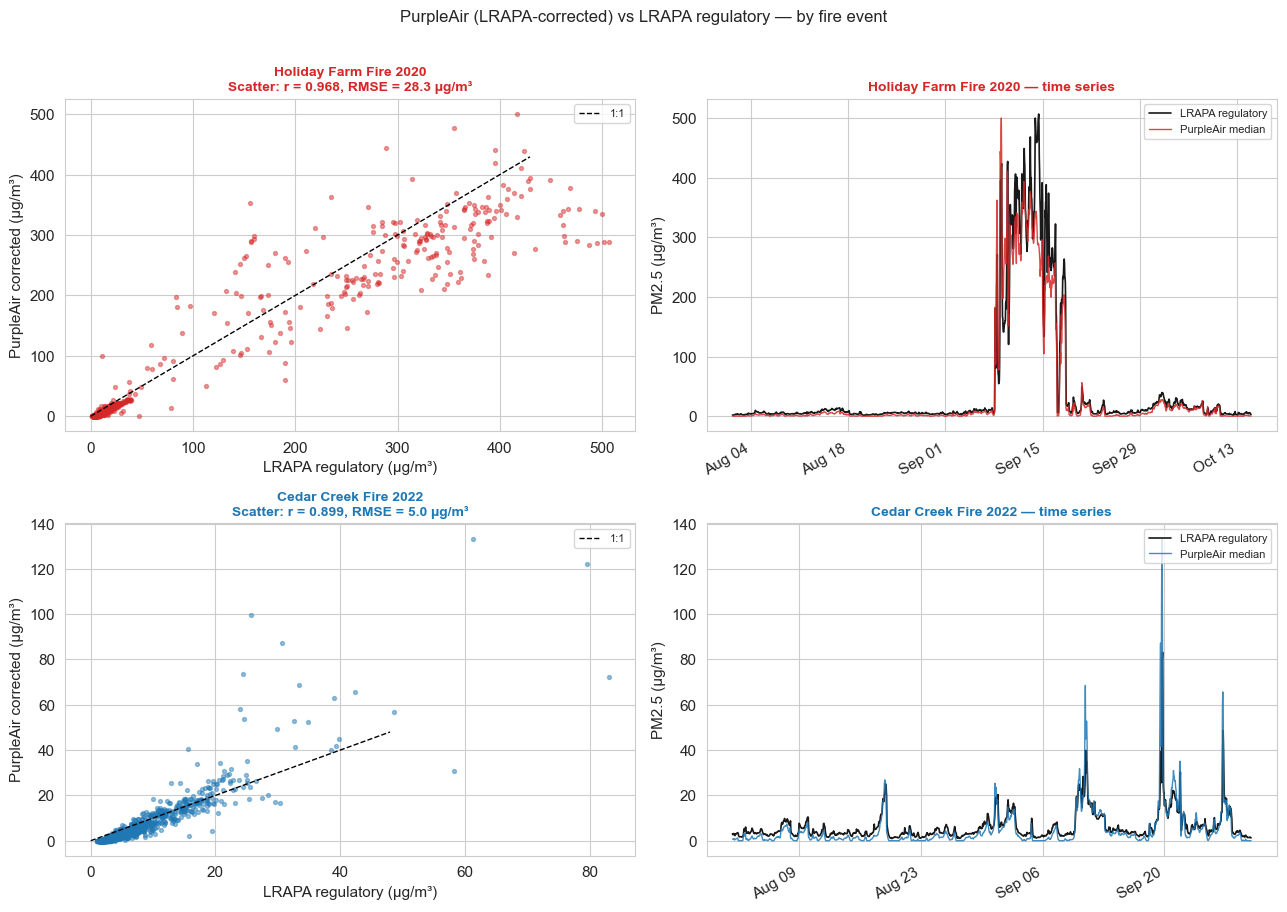

In [5]:
# Aggregate PA to hourly median for validation
pa_hourly_val = pa_clean.groupby('timestamp')['pm2.5_lrapa'].median().reset_index()
pa_hourly_val.columns = ['timestamp', 'pm2.5_pa_corrected']

val = pd.merge(
    pa_hourly_val,
    lrapa_raw[['timestamp', 'pm2.5_lrapa_regulatory']],
    on='timestamp',
    how='inner',
).dropna()

event_map = {2020: 'Holiday Farm Fire 2020', 2022: 'Cedar Creek Fire 2022'}
val['event'] = val['timestamp'].dt.year.map(event_map)
events = [e for e in event_map.values() if e in val['event'].values]
event_colors = {'Holiday Farm Fire 2020': '#d62728', 'Cedar Creek Fire 2022': '#1f77b4'}

print(f'Overlapping timestamps (pooled): {len(val):,}\n')

# Per-event stats
for ev in events:
    sub = val[val['event'] == ev]
    r, p = stats.pearsonr(sub['pm2.5_pa_corrected'], sub['pm2.5_lrapa_regulatory'])
    rmse = np.sqrt(((sub['pm2.5_pa_corrected'] - sub['pm2.5_lrapa_regulatory']) ** 2).mean())
    bias = (sub['pm2.5_pa_corrected'] - sub['pm2.5_lrapa_regulatory']).mean()
    print(f'{ev}  (n = {len(sub):,})')
    print(f'  Pearson r:  {r:.3f}  (p = {p:.2e})')
    print(f'  RMSE:       {rmse:.2f} µg/m³')
    print(f'  Mean bias:  {bias:+.2f} µg/m³  (PA − regulatory)\n')

r_all, _ = stats.pearsonr(val['pm2.5_pa_corrected'], val['pm2.5_lrapa_regulatory'])
rmse_all = np.sqrt(((val['pm2.5_pa_corrected'] - val['pm2.5_lrapa_regulatory']) ** 2).mean())
print(f'Pooled (both events): r = {r_all:.3f}, RMSE = {rmse_all:.2f} µg/m³')

# Side-by-side: row = event, col = scatter | time series
n_ev = len(events)
fig, axes = plt.subplots(n_ev, 2, figsize=(13, 4.5 * n_ev), squeeze=False)

for row, ev in enumerate(events):
    sub = val[val['event'] == ev].sort_values('timestamp')
    color = event_colors[ev]
    r, _ = stats.pearsonr(sub['pm2.5_pa_corrected'], sub['pm2.5_lrapa_regulatory'])
    rmse = np.sqrt(((sub['pm2.5_pa_corrected'] - sub['pm2.5_lrapa_regulatory']) ** 2).mean())

    ax = axes[row, 0]
    lim = max(sub['pm2.5_pa_corrected'].quantile(0.99),
              sub['pm2.5_lrapa_regulatory'].quantile(0.99))
    ax.scatter(sub['pm2.5_lrapa_regulatory'], sub['pm2.5_pa_corrected'],
               s=8, alpha=0.45, color=color)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1')
    ax.set_xlabel('LRAPA regulatory (µg/m³)')
    ax.set_ylabel('PurpleAir corrected (µg/m³)')
    ax.set_title(f'{ev}\nScatter: r = {r:.3f}, RMSE = {rmse:.1f} µg/m³',
                 fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(sub['timestamp'], sub['pm2.5_lrapa_regulatory'],
            color='black', linewidth=1.2, label='LRAPA regulatory', alpha=0.9)
    ax.plot(sub['timestamp'], sub['pm2.5_pa_corrected'],
            color=color, linewidth=1, label='PurpleAir median', alpha=0.85)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{ev} — time series', fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('PurpleAir (LRAPA-corrected) vs LRAPA regulatory — by fire event',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_vs_lrapa_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Build Final Analysis Dataset

In [6]:
df = create_full_analysis_dataset(
    purpleair_df=pa_raw,
    noaa_df=noaa_eug,
    lrapa_df=lrapa_raw,
    noaa_station=None,   # already filtered above
    add_features=True,
    remove_outliers=False
)
df.head(3)

=== Creating Full Analysis Dataset ===

1. Cleaning NOAA data...
Removed 1 duplicate timestamps

2. Cleaning PurpleAir data (A/B QC + LRAPA correction)...
A/B QC: flagged 6943 records (8.0%) with channel disagreement
Dropped 6943 A/B-flagged records
Applied LRAPA correction to 'pm2.5_cf_1_a / pm2.5_cf_1 (coalesced)' → 'pm2.5_lrapa'
Aggregated 52 sensors → 3240 hourly timestamps

3. Preparing LRAPA regulatory data...
   3288 LRAPA hourly records

4. Merging all three datasets on timestamp...
   Final dataset: 3240 records
   Date range:    2020-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00

5. Adding features...
   Rolling/lag features computed within each fire event (no cross-season leakage)

Missing values:
pm2.5_alt                        1800
pm2.5_alt_a_std                  1800
pm2.5_atm                        1800
pm2.5_atm_a_std                  1800
snowdepth                        3240
temperature_f                       1
temperature_c                       1
dewpoint_f   

,timestamp,pm2.5_lrapa,pm2.5_lrapa_std,pm2.5_cf1_raw,pm2.5_cf1_raw_std,pm2.5_alt,pm2.5_alt_a_std,pm2.5_atm,pm2.5_atm_a_std,n_sensors,...,wind_speed_mph_lag_1h,wind_speed_mph_lag_3h,wind_speed_mph_lag_6h,wind_speed_mph_lag_12h,wind_speed_mph_lag_24h,pressure_hpa_lag_1h,pressure_hpa_lag_3h,pressure_hpa_lag_6h,pressure_hpa_lag_12h,pressure_hpa_lag_24h
0,2020-07-31 17:00:00-07:00,0.151667,0.157182,1.558333,0.398767,NaN,NaN,NaN,NaN,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-07-31 18:00:00-07:00,0.150000,0.236643,1.458333,0.611196,NaN,NaN,NaN,NaN,12,...,12.65858,NaN,NaN,NaN,NaN,1016.3,NaN,NaN,NaN,NaN
2,2020-07-31 19:00:00-07:00,0.011667,0.040415,0.650000,0.377793,NaN,NaN,NaN,NaN,12,...,12.65858,NaN,NaN,NaN,NaN,1016.9,NaN,NaN,NaN,NaN


In [7]:
print("=== Final Dataset Summary ===")
print(f"Records:  {len(df):,}")
print(f"Columns:  {len(df.columns)}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nKey columns: {[c for c in df.columns if not c.endswith(('_std','_rolling','_lag'))]}")
print(f"\nDescriptive stats (PM2.5 + weather):")
key_cols = ['pm2.5_lrapa', 'pm2.5_cf1_raw', 'pm2.5_lrapa_regulatory',
            'temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(2)

=== Final Dataset Summary ===
Records:  3,240
Columns:  87
Date range: 2020-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00

Key columns: ['timestamp', 'pm2.5_lrapa', 'pm2.5_cf1_raw', 'pm2.5_alt', 'pm2.5_atm', 'n_sensors', 'snowdepth', 'temperature_f', 'temperature_c', 'dewpoint_f', 'dewpoint_c', 'humidity', 'pressure_hpa', 'wind_speed_knots', 'wind_speed_mph', 'wind_speed_mps', 'wind_direction', 'precipitation_in', 'precipitation_mm', 'visibility_miles', 'visibility_km', 'pm2.5_lrapa_regulatory', 'year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear', 'week', 'season', 'is_weekend', 'event', 'wind_dir_sin', 'wind_dir_cos', 'pm2.5_lrapa_rolling_mean_3h', 'pm2.5_lrapa_rolling_std_3h', 'pm2.5_lrapa_rolling_mean_6h', 'pm2.5_lrapa_rolling_std_6h', 'pm2.5_lrapa_rolling_mean_12h', 'pm2.5_lrapa_rolling_std_12h', 'pm2.5_lrapa_rolling_mean_24h', 'pm2.5_lrapa_rolling_std_24h', 'temperature_f_rolling_mean_3h', 'temperature_f_rolling_std_3h', 'temperature_f_rolling_mean_6h', 'temperature_f_roll

,pm2.5_lrapa,pm2.5_cf1_raw,pm2.5_lrapa_regulatory,temperature_f,humidity,wind_speed_mph,pressure_hpa
count,3240.00,3240.00,3222.00,3239.00,3239.00,3237.00,3238.00
mean,24.62,50.43,28.51,66.55,64.57,6.64,1016.28
std,73.50,147.03,80.18,11.08,21.53,4.91,3.76
min,0.00,0.02,0.95,45.00,13.26,0.00,1002.50
25%,0.78,2.74,3.46,58.00,46.70,3.45,1013.90
50%,2.28,5.86,5.46,64.00,67.86,5.75,1016.10
75%,7.72,16.76,10.89,74.00,83.29,9.21,1018.70
max,502.52,1006.35,506.98,101.00,100.00,27.62,1032.20


In [8]:
# event column is set inside create_full_analysis_dataset (before lags/rolls)
print('Event breakdown:')
print(df['event'].value_counts().to_string())
print()
df.to_csv('../data/processed/analysis_data.csv', index=False)
print(f'Saved {len(df):,} records to data/processed/analysis_data.csv')


Event breakdown:
event
Holiday Farm Fire 2020    1800
Cedar Creek Fire 2022     1440

Saved 3,240 records to data/processed/analysis_data.csv
